In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed/analysis_zomato.csv"
)

In [2]:
print("Total Restaurants:", df.shape[0])

print("Total Locations:",
      df["location"].nunique())

print("Total Restaurant Types:",
      df["rest_type"].nunique())

print("Total Cuisines:",
      df["cuisines"].nunique())

Total Restaurants: 51352
Total Locations: 93
Total Restaurant Types: 94
Total Cuisines: 2715


In [3]:
top_locations = (
    df["location"]
    .value_counts()
    .head(10)
)

top_locations

location
BTM                      5098
HSR                      2508
Koramangala 5th Block    2481
JP Nagar                 2230
Whitefield               2125
Indiranagar              2038
Jayanagar                1918
Marathahalli             1826
Bannerghatta Road        1617
Bellandur                1286
Name: count, dtype: int64

In [4]:
cuisine_counts = (
    df["cuisines"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

cuisine_counts

cuisines
North Indian    20963
Chinese         15451
South Indian     8590
Fast Food        8070
Biryani          6476
Continental      5721
Desserts         5598
Cafe             5251
Beverages        4701
Italian          3364
Name: count, dtype: int64

In [5]:
location_rating = (
    df.groupby("location")["rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

location_rating

location
Lavelle Road             4.141788
Koramangala 3rd Block    4.020419
St. Marks Road           4.017201
Koramangala 5th Block    4.006661
Church Street            3.992125
Sankey Road              3.965385
Koramangala 4th Block    3.918668
Cunningham Road          3.901053
Residency Road           3.864570
Koramangala 7th Block    3.852986
Name: rate, dtype: float64

In [6]:
online_rating = (
    df.groupby("online_order")["rate"]
    .mean()
)

online_rating

online_order
No     3.658071
Yes    3.722527
Name: rate, dtype: float64

In [7]:
booking_rating = (
    df.groupby("book_table")["rate"]
    .mean()
)

booking_rating

book_table
No     3.620845
Yes    4.143464
Name: rate, dtype: float64

In [8]:
top_votes = (
    df[["name","votes","location","rate"]]
    .sort_values("votes", ascending=False)
    .head(10)
)

top_votes

,name,votes,location,rate
49284,Byg Brewski Brewing Company,16832,Sarjapur Road,4.9
49712,Byg Brewski Brewing Company,16832,Sarjapur Road,4.9
48831,Byg Brewski Brewing Company,16832,Sarjapur Road,4.9
4789,Byg Brewski Brewing Company,16345,Sarjapur Road,4.9
4931,Byg Brewski Brewing Company,16345,Sarjapur Road,4.9
3913,Byg Brewski Brewing Company,16345,Sarjapur Road,4.9
19195,Toit,14956,Indiranagar,4.7
18574,Toit,14956,Indiranagar,4.7
36461,Truffles,14726,Koramangala 5th Block,4.7
33725,Truffles,14723,Koramangala 5th Block,4.7


In [9]:
expensive_locations = (
    df.groupby("location")
      ["approx_cost(for two people)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

expensive_locations

location
Sankey Road         2505.555556
Race Course Road    1309.352518
Lavelle Road        1307.934990
MG Road             1155.704698
Infantry Road       1062.251656
Residency Road       966.320475
Langford Town        883.333333
St. Marks Road       871.306818
Cunningham Road      864.969450
Church Street        834.885764
Name: approx_cost(for two people), dtype: float64

In [14]:
df = pd.read_csv(
    "../data/processed/final_zomato.csv"
)

In [15]:
print("success_score" in df.columns)

True


In [16]:
corr_df = df[
    [
        "rate",
        "votes",
        "approx_cost(for two people)",
        "success_score"
    ]
]

corr_df.corr()

,rate,votes,approx_cost(for two people),success_score
rate,1.000000,0.399944,0.326949,0.972644
votes,0.399944,1.000000,0.353343,0.449960
approx_cost(for two people),0.326949,0.353343,1.000000,0.340979
success_score,0.972644,0.449960,0.340979,1.000000


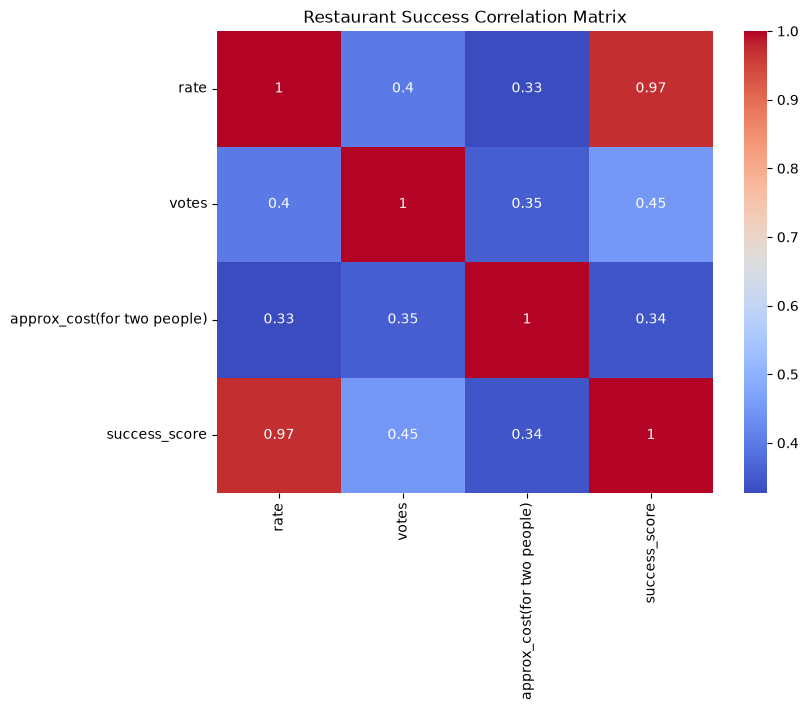

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Restaurant Success Correlation Matrix")

plt.show()

In [18]:
corr_df.corr()

,rate,votes,approx_cost(for two people),success_score
rate,1.000000,0.399944,0.326949,0.972644
votes,0.399944,1.000000,0.353343,0.449960
approx_cost(for two people),0.326949,0.353343,1.000000,0.340979
success_score,0.972644,0.449960,0.340979,1.000000
